# MNIST handwritten digits classification with CNNs

In this notebook, we'll train a convolutional neural network (CNN, ConvNet) to classify MNIST digits using PyTorch


First, the needed imports. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt

print(f"[INFO] Torch infos: {torch.__version__}")

[INFO] Torch infos: 2.9.1+cu128


In [12]:
import torch
print(torch.cuda.is_available())
# Should print: True

True


### Define the CNN 

Try to avoid hardcoding when you efine your CNN.

In [2]:
class MyCNN(nn.Module):
    def __init__(self, 
                 number_of_output_classes: int, 
                 input_size: tuple[int, int],
                 kernel_size: int, 
                 padding_size: int, 
                 pooling_size: int,
                 input_channels: int, 
                 dropout_probabilities: float, 
                 dense_units: list[int], 
                 layers_list: list[int]):
        
        super().__init__()
        
        layers = []
        input_units = input_channels
        for output_units in layers_list:
            # hidden layers
            layers += [
                nn.Conv2d(input_units, output_units, kernel_size=kernel_size, padding=padding_size),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(pooling_size),
            ]
            input_units = output_units
        
        # create features
        self.features = nn.Sequential(*layers)
        self.flatten_layer = nn.Flatten()

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_size[0], input_size[1])
            flat_dim = self.flatten_layer(self.features(dummy)).shape[1]

        mlp = []
        in_features = flat_dim
        for h in dense_units:
            mlp += [
                nn.Linear(in_features, h),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout_probabilities),
            ]
            in_features = h

        # add final classifier
        self.classifier = nn.Sequential(*mlp)
        self.final_classifier =  nn.Linear(in_features, number_of_output_classes)
        

    def forward(self, x):
        x = self.features(x)
        x = self.flatten_layer(x)
        x = self.classifier(x)
        x = self.final_classifier(x)
        return x

### We need to define train validation and test loops

In [3]:
def unnormalize_mnist(x, mean=0.1307, std=0.3081):
    return x * std + mean

# here handler that take care about trainer
@torch.no_grad() 
def evaluate(model, loader, criterion, device):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0    

    for image, label in loader:
        #send image to device 
        image = image.to(device)
        label = label.to(device)

        # calculate the loss 
        logits = model(image)
        loss = criterion(logits, label)
        current_image_loss = loss.item()
        
        # calculate batch loss 
        running_loss += current_image_loss * image.size(0)

        # calculate prediction now
        prediction = logits.argmax(dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)
    
    #true average loss per sample over the whole epoch
    return running_loss / total, correct / total 

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # at the start of each training step you clear gradients from the previous batch
        optimizer.zero_grad()
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        # computes gradients of the loss every parameter of the model running backpropagation 
        loss.backward()

        # This updates the model parameters using the gradients just computed
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def predict_batch(model, images, device, class_names=None, topk=1):
    model.eval()
    images = images.to(device)

    logits = model(images)                  
    probs = F.softmax(logits, dim=1)        

    top_probs, top_idxs = probs.topk(topk, dim=1)  

    results = []
    for i in range(images.size(0)):
        preds = []
        for k in range(topk):
            idx = int(top_idxs[i, k].item())
            p = float(top_probs[i, k].item())
            label = class_names[idx] if class_names else idx
            preds.append({"label": label, "index": idx, "prob": p})
        results.append({"topk": preds})
    return results


### Plots functions

In [4]:
def plot_curves(history):
    # Loss
    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


@torch.no_grad()
def visualize_predictions(model, test_loader, device, n=16):
    model.eval()

    images, labels = next(iter(test_loader))
    images, labels = images[:n], labels[:n]

    results = predict_batch(model, images, device=device, class_names=None, topk=1)

    cols = int(n ** 0.5)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(2.5 * cols, 2.5 * rows))
    for i in range(n):
        img = unnormalize_mnist(images[i]).squeeze(0)  # (H, W)
        gt = int(labels[i].item())
        pred = results[i]["topk"][0]["index"]
        prob = results[i]["topk"][0]["prob"]

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img.cpu().numpy(), cmap="gray")
        ax.set_title(f"GT:{gt}  Pred:{pred}\nP:{prob:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def compute_confusion_matrix(model, loader, device, num_classes=10):
    model.eval()
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64) 

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        for t, p in zip(labels.view(-1), preds.view(-1)):
            cm[t.long(), p.long()] += 1

    return cm


def plot_confusion_matrix(cm, class_names=None, normalize=False, title="Confusion Matrix"):
    cm_plot = cm.clone().float()

    if normalize:
        # normalize rows (per true class)
        row_sums = cm_plot.sum(dim=1, keepdim=True).clamp(min=1)
        cm_plot = cm_plot / row_sums

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot.cpu().numpy(), interpolation="nearest")
    plt.title(title + (" (normalized)" if normalize else ""))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    n = cm.shape[0]
    if class_names is None:
        class_names = list(range(n))

    plt.xticks(range(n), class_names)
    plt.yticks(range(n), class_names)

    # Write values inside cells 
    for i in range(n):
        for j in range(n):
            val = cm_plot[i, j].item()
            if normalize:
                text = f"{val:.2f}"
            else:
                text = f"{int(cm[i, j].item())}"
            plt.text(j, i, text, ha="center", va="center")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def show_misclassified_examples(model, loader, device, max_examples=25, class_names=None):
    model.eval()
    mis_images, mis_labels, mis_preds, mis_probs = [], [], [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        wrong_mask = preds != labels
        if wrong_mask.any():
            wrong_images = images[wrong_mask].detach().cpu()
            wrong_labels = labels[wrong_mask].detach().cpu()
            wrong_preds = preds[wrong_mask].detach().cpu()
            wrong_probs = probs[wrong_mask].max(dim=1).values.detach().cpu()

            for img, y, p, pr in zip(wrong_images, wrong_labels, wrong_preds, wrong_probs):
                mis_images.append(img)
                mis_labels.append(int(y.item()))
                mis_preds.append(int(p.item()))
                mis_probs.append(float(pr.item()))
                if len(mis_images) >= max_examples:
                    break

        if len(mis_images) >= max_examples:
            break

    if len(mis_images) == 0:
        print(" [INFO] No misclassified examples found")
        return

    n = len(mis_images)
    cols = int(n ** 0.5)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(2.7 * cols, 2.7 * rows))
    for i in range(n):
        img = unnormalize_mnist(mis_images[i]).squeeze(0)  # (H, W)

        gt = mis_labels[i]
        pred = mis_preds[i]
        prob = mis_probs[i]

        gt_name = class_names[gt] if class_names else gt
        pred_name = class_names[pred] if class_names else pred

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img.numpy(), cmap="gray")
        ax.set_title(f"GT:{gt_name}  Pred:{pred_name}\nP:{prob:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


### Let's get the data 

In [5]:
# let s get the data

mnist_mean, mnist_std = 0.1307, 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,)),
])

# load the and train 
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


100.0%
100.0%
100.0%
100.0%


### NOte that we do not have validation we need to create it

In [6]:
val_ratio = 0.2
val_size = int(len(train_dataset) * val_ratio)
train_size = len(train_dataset) - val_size
train_dataset, validation_dataset = random_split(train_dataset, [train_size, val_size])

In [7]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
validation_loader = DataLoader(validation_dataset, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

### Let s deploy the CNN and it s parameters

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEVICE] {device}")

cnn_parameters = {
    "number_of_output_classes": 10,
    "kernel_size": 3,
    "padding_size": 1,
    "pooling_size": 2,
    "input_channels": 1,
    "input_size": (28, 28),
    "dropout_probabilities": 0.2,
    "dense_units": [128],
    "layers_list": [16, 32, 64],
}

model = MyCNN(**cnn_parameters).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_function = nn.CrossEntropyLoss()

epochs = 15
best_val_acc = 0.0

# I like to store stuff into dict 
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

[DEVICE] cuda


### Training loop

In [9]:
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model=model, 
                                            loader=train_loader, 
                                            criterion=loss_function, 
                                            optimizer=optimizer, 
                                            device=device)

    val_loss, val_acc = evaluate(model=model, 
                                 loader=validation_loader, 
                                 criterion=loss_function, 
                                 device=device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"[EPOCH {epoch:02d}/{epochs}] train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "cnn_mnist.pt")

print("[DONE] Best val acc:", best_val_acc)

[EPOCH 01/15] train_loss=0.3186 train_acc=0.9004 | val_loss=0.0874 val_acc=0.9725
[EPOCH 02/15] train_loss=0.0848 train_acc=0.9742 | val_loss=0.0529 val_acc=0.9832
[EPOCH 03/15] train_loss=0.0586 train_acc=0.9822 | val_loss=0.0431 val_acc=0.9869
[EPOCH 04/15] train_loss=0.0468 train_acc=0.9856 | val_loss=0.0382 val_acc=0.9876
[EPOCH 05/15] train_loss=0.0384 train_acc=0.9882 | val_loss=0.0465 val_acc=0.9868
[EPOCH 06/15] train_loss=0.0325 train_acc=0.9894 | val_loss=0.0315 val_acc=0.9898
[EPOCH 07/15] train_loss=0.0281 train_acc=0.9909 | val_loss=0.0298 val_acc=0.9900
[EPOCH 08/15] train_loss=0.0244 train_acc=0.9921 | val_loss=0.0343 val_acc=0.9893
[EPOCH 09/15] train_loss=0.0240 train_acc=0.9924 | val_loss=0.0427 val_acc=0.9874
[EPOCH 10/15] train_loss=0.0214 train_acc=0.9932 | val_loss=0.0311 val_acc=0.9901
[EPOCH 11/15] train_loss=0.0180 train_acc=0.9939 | val_loss=0.0282 val_acc=0.9912
[EPOCH 12/15] train_loss=0.0168 train_acc=0.9943 | val_loss=0.0396 val_acc=0.9897
[EPOCH 13/15] tr

### Plot History and predictions

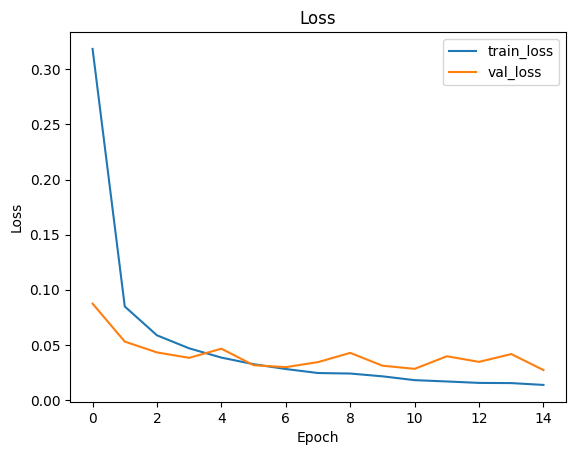

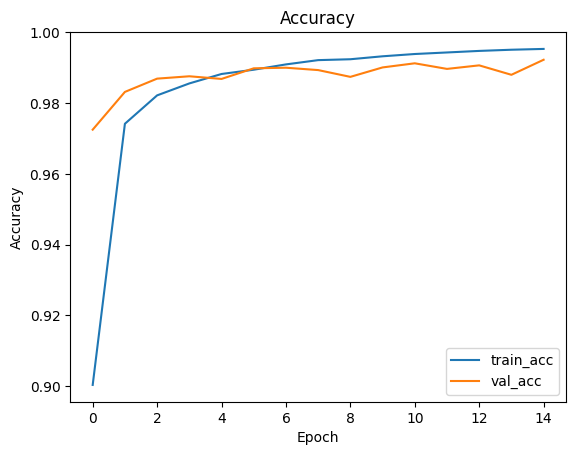

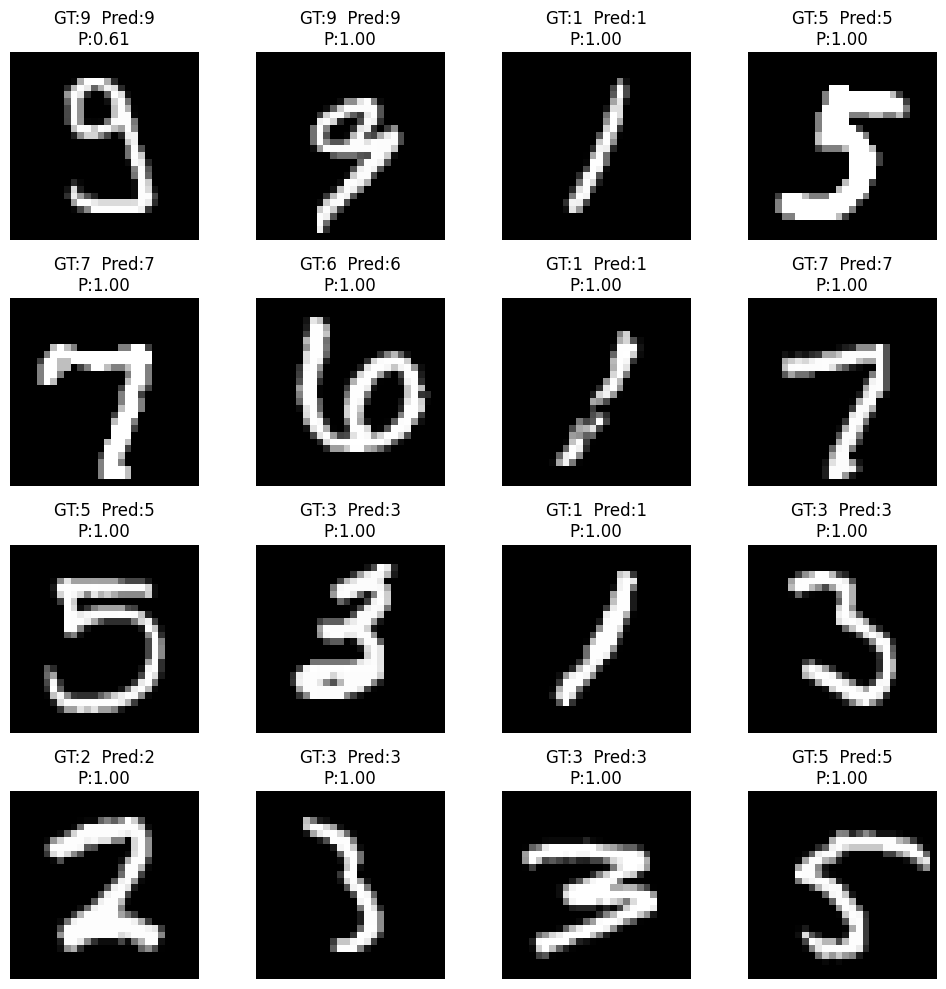

In [10]:
# Plot learning curves
plot_curves(history)

# Visualize predictions on the test set
visualize_predictions(model, test_loader, device, n=16)

### Collect evaluation informations

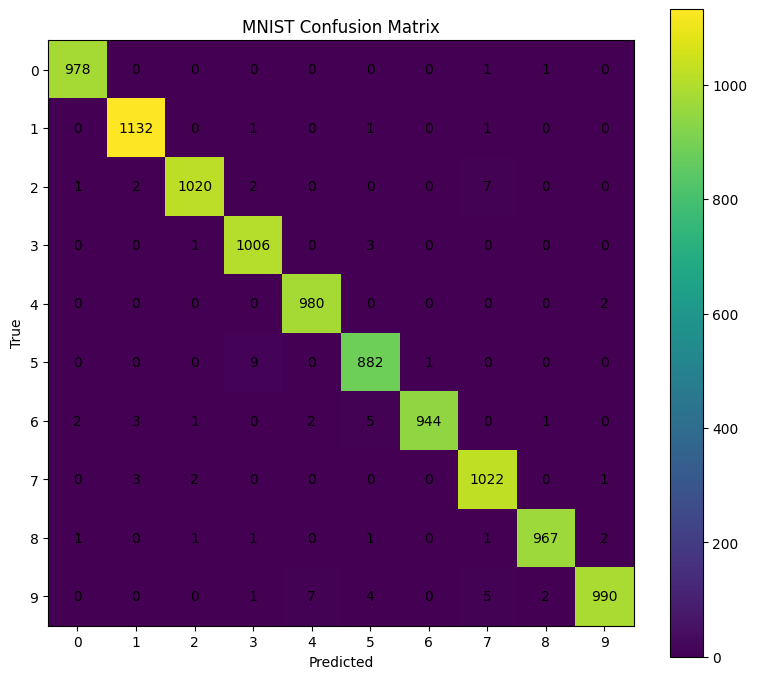

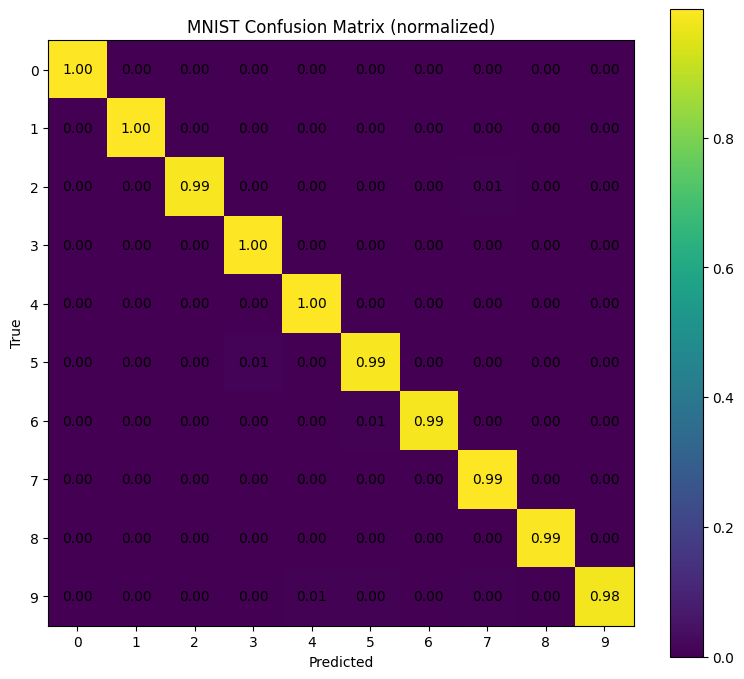

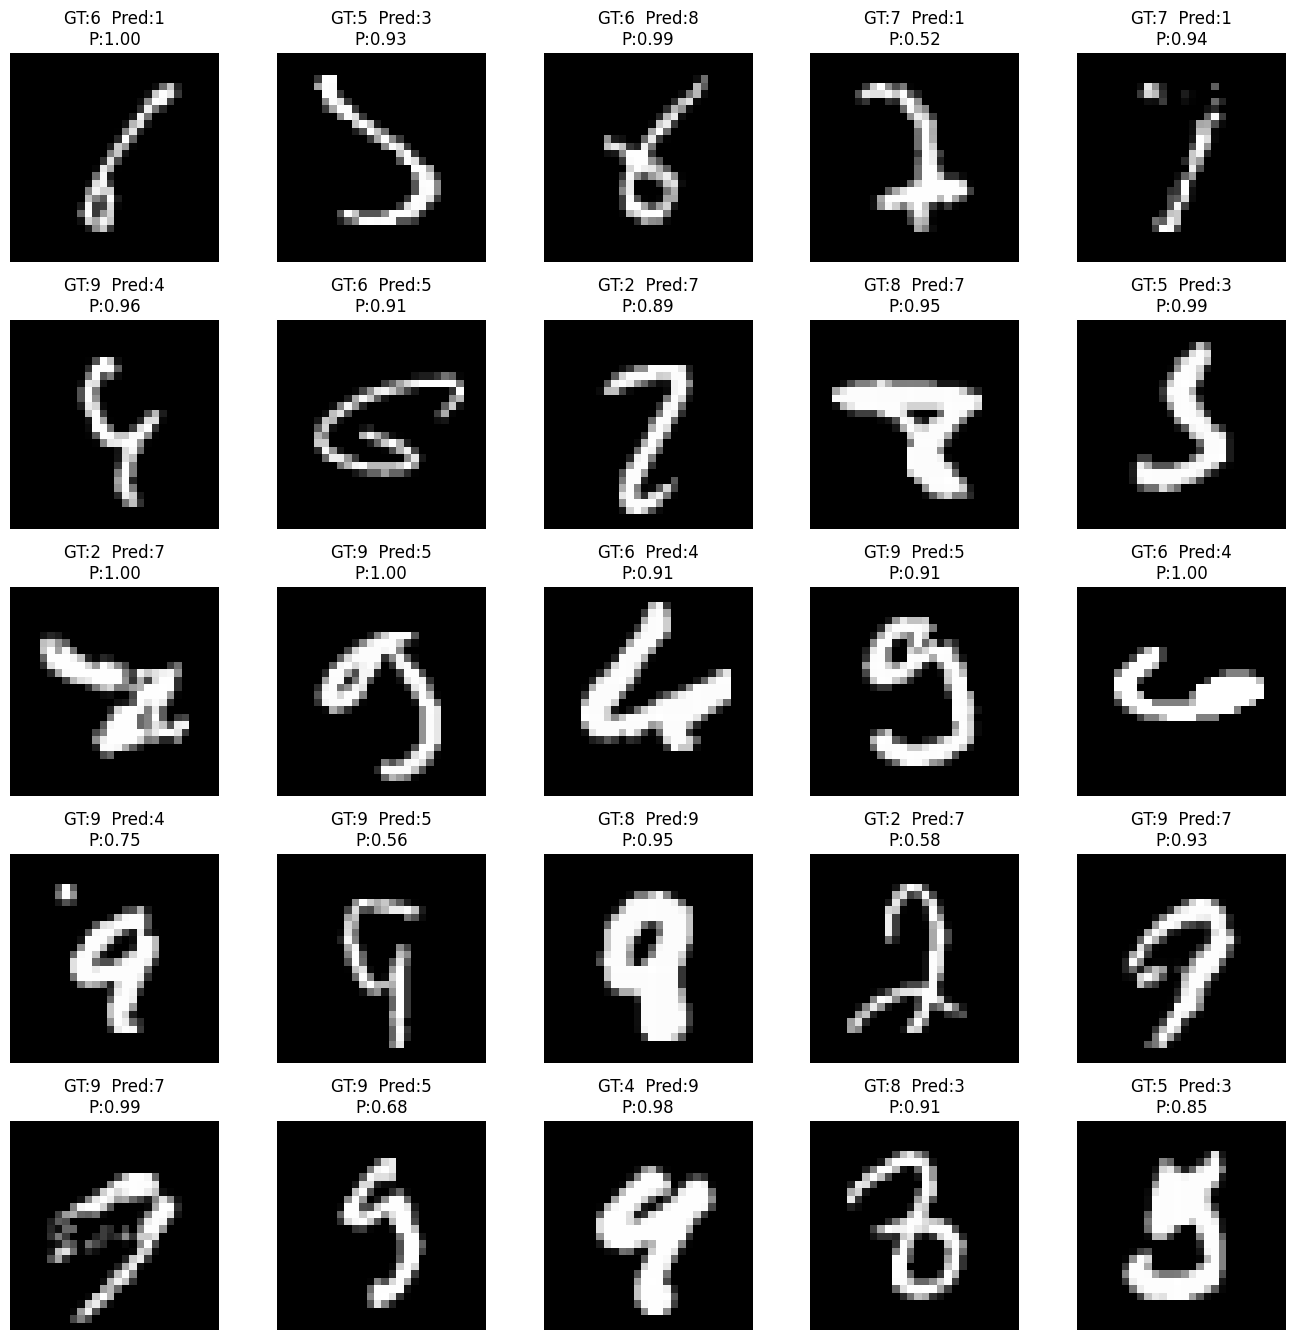

In [11]:
# Confusion matrix on test set
cm = compute_confusion_matrix(model, test_loader, device, num_classes=10)
plot_confusion_matrix(cm, class_names=list(range(10)), normalize=False, title="MNIST Confusion Matrix")
plot_confusion_matrix(cm, class_names=list(range(10)), normalize=True, title="MNIST Confusion Matrix")

# Show only misclassified examples
show_misclassified_examples(model, test_loader, device, max_examples=25, class_names=list(range(10)))